In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [21]:
#load dataset
df = pd.read_csv('diabetes_bagging.csv')

print(f"\n Dataset Shape  : {df.shape}")
print(f" Columns        : {list(df.columns)}")
print(f"\n First 5 Rows:\n{df.head()}")
print(f"\n Class Distribution:\n{df['Outcome'].value_counts().rename({0:'No Diabetes (0)', 1:'Diabetes (1)'})}")
print(f"\n Missing Values :\n{df.isnull().sum()}")


 Dataset Shape  : (120, 6)
 Columns        : ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'Outcome']

 First 5 Rows:
   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1

 Class Distribution:
Outcome
Diabetes (1)       74
No Diabetes (0)    46
Name: count, dtype: int64

 Missing Values :
Glucose          0
BMI              0
Age              0
BloodPressure    0
Insulin          0
Outcome          0
dtype: int64


In [22]:
#feature /target split
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

feature_names = list(X.columns)
print(f"\n Features Used  : {feature_names}")


 Features Used  : ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n Train Size: {X_train.shape[0]}    Test Size: {X_test.shape[0]}")


 Train Size: 96    Test Size: 24


In [24]:
#decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_cm  = confusion_matrix(y_test, y_pred_dt)

print("  DECISION TREE (Baseline)")
print(f"  Accuracy : {dt_acc * 100:.2f}%\n")
print(classification_report(
    y_test, y_pred_dt,
    target_names=["No Diabetes", "Diabetes"]
))

  DECISION TREE (Baseline)
  Accuracy : 95.83%

              precision    recall  f1-score   support

 No Diabetes       0.90      1.00      0.95         9
    Diabetes       1.00      0.93      0.97        15

    accuracy                           0.96        24
   macro avg       0.95      0.97      0.96        24
weighted avg       0.96      0.96      0.96        24



In [25]:
#bagging classifier 
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)

bag_acc = accuracy_score(y_test, y_pred_bag)
bag_cm  = confusion_matrix(y_test, y_pred_bag)

print("  BAGGING CLASSIFIER (50 Trees)")
print(f"  Accuracy : {bag_acc * 100:.2f}%\n")
print(classification_report(
    y_test, y_pred_bag,
    target_names=["No Diabetes", "Diabetes"]
))

  BAGGING CLASSIFIER (50 Trees)
  Accuracy : 100.00%

              precision    recall  f1-score   support

 No Diabetes       1.00      1.00      1.00         9
    Diabetes       1.00      1.00      1.00        15

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



### COMPARISON

In [26]:
improvement = (bag_acc - dt_acc) * 100

print("  ACCURACY COMPARISON")
print(f"  Decision Tree  : {dt_acc  * 100:.2f}%")
print(f"  Bagging        : {bag_acc * 100:.2f}%")
print(f"  Improvement    : {improvement:+.2f}%")


  ACCURACY COMPARISON
  Decision Tree  : 95.83%
  Bagging        : 100.00%
  Improvement    : +4.17%


### VISUALIZATION

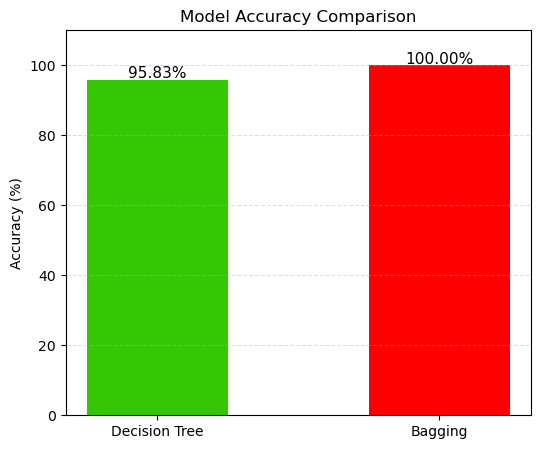

In [27]:
plt.figure(figsize=(6, 5))

models = ["Decision Tree", "Bagging"]
accuracies = [dt_acc * 100, bag_acc * 100]
colors = ["#35c704", "#ff0000"]

bars = plt.bar(models, accuracies, color=colors, width=0.5)

# value labels
for bar, val in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.5,
        f"{val:.2f}%",
        ha="center",
        fontsize=11
    )

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [28]:
def plot_custom_cm(cm, title, ax):
    import numpy as np
    import matplotlib.pyplot as plt

    color_map = np.empty(cm.shape, dtype=object)

    for i in range(2):
        for j in range(2):
            if i == 0 and j == 0:   # TN
                color_map[i, j] = "#EEFF00"
            elif i == 1 and j == 1: # TP
                color_map[i, j] = "#00FF22"
            elif i == 0 and j == 1: # FP
                color_map[i, j] = "#9999FF"
            elif i == 1 and j == 0: # FN
                color_map[i, j] = "#FF9999"

    # Draw cells
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color=color_map[i, j]))

            ax.text(j + 0.5, i + 0.5,
                    cm[i, j],
                    ha="center", va="center",
                    fontsize=14, fontweight="bold")

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)

    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(["0", "1"])

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

    ax.invert_yaxis()
    ax.grid(False)

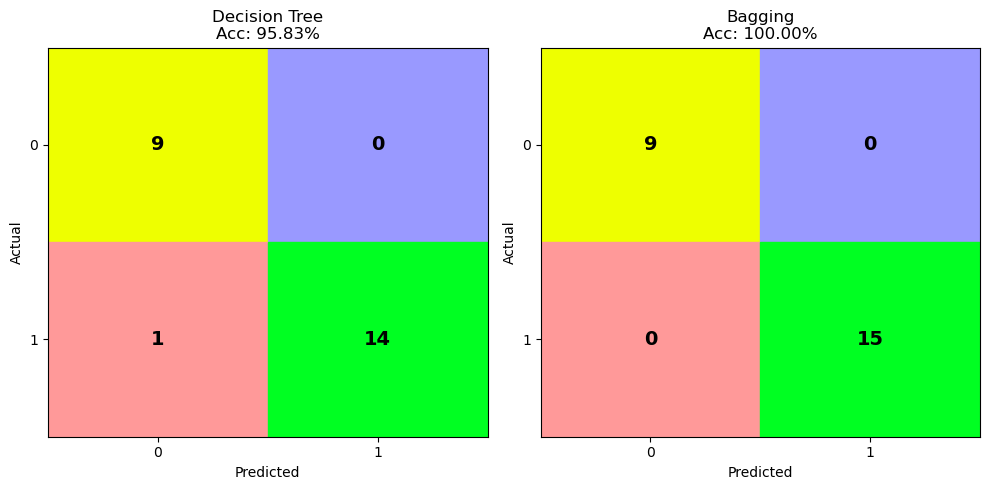

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_custom_cm(
    dt_cm,
    f"Decision Tree\nAcc: {dt_acc*100:.2f}%",
    axes[0]
)

plot_custom_cm(
    bag_cm,
    f"Bagging\nAcc: {bag_acc*100:.2f}%",
    axes[1]
)

plt.tight_layout()
plt.show()